# Class 22: Partial Differential Equations Part 2

Ch. 9, sections 3: Partial Differential Equations  
- Initial value problems
    - the FTCS method 

Complete the activities as instructed by the professor

#### Import any packages we need below (update as we go):

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random 

### Initial Value Partial Differential Equations Problems: the FTCS method

**Example 9.3**: The Heat Equation 

The flat base of a container made of 1 cm thick stainless steel is initially at a uniform temperature of $20^\circ$ C everywhere. The container is placed in a bath of cold water at $0^\circ$ C and filled with hot water at $50^\circ$ C. 

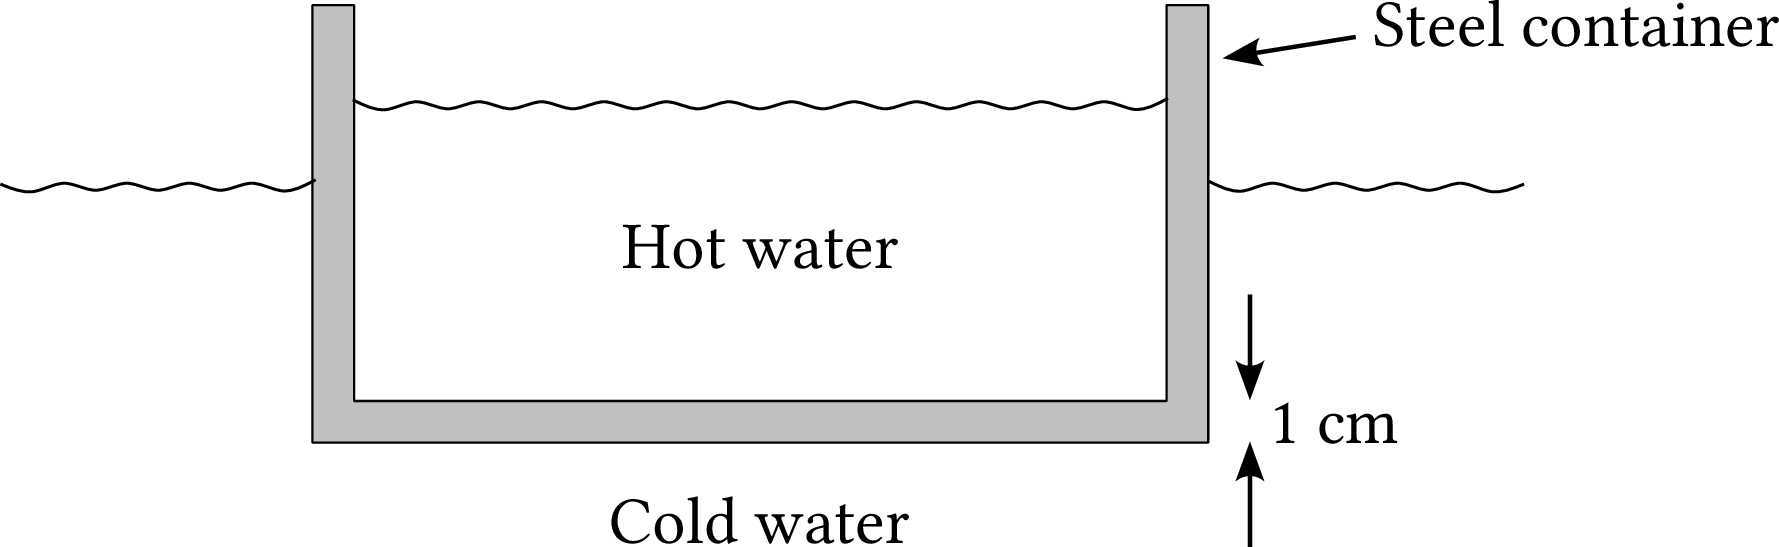

Our goal is to calculate the temperature profile of the steel as a function of distance $x$ from the hot side to the cold side, and as a function of time. For simplicity, let's treat the base of the container as being arbitrarily wide, so that its temperature profile is the same everywhere, and assume that neither the hot nor the cold water changes temperature appreciably. 

Thermal conduction is goverened by the diffusion equation, so solving this problem is a matter of solving the one-dimensional diffusion equation for the temperature $T$: 

$$ \frac{\partial T}{\partial t} = D \frac{\partial^2 T}{\partial x^2} $$

where $T$ is the temperature and $D$ is the heat diffusion coefficient, also called the thermal diffusivity. Let us divide the $x$-axis into 200 equal grid intervals, meaning that there will be 201 grid points in total, counting the first and last ones. The first and last points have fixed temperatures of $50^\circ$ C and $0^\circ$ C, respectively, while the intermediate points are initially all at $20^\circ$ C. We also need the heat diffusion coefficient for stainless steel (thermal diffusivity), which is $D = 4.25 \times 10^{-6}$ $\text{ m}^2\text{s}^{-1}$. 

We will calculate this using the FTCS method, and plot the temperature profile at times $t = 0.01, 0.1, 0.4, 1.0,$ and $10.0$ s all on the same graph. 

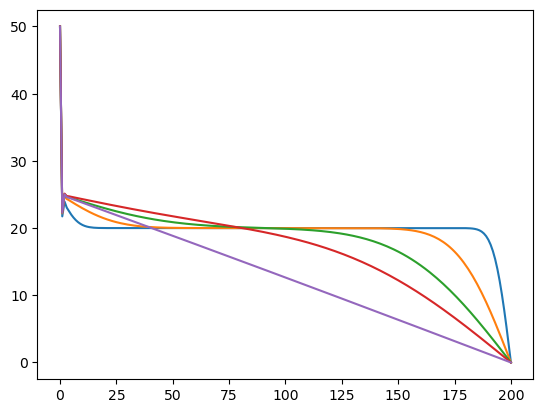

In [8]:
# constants
D = 4.25e-6
N = 200
L = 0.01 #steel thickness in meters
a = L/N
h = 1e-4

# temps
Tlow = 0.0
Thigh = 50.0
Tmid = 20.0

T = np.ones(N+1, float)* Tmid
T[0] = Thigh
T[-1] = Tlow
Tp = np.zeros(N+1, float)

# interesting times
t1 = 0.01
t3 = 0.1
t2 = 0.4
t4 = 1.0
t5 = 10.0
epsilon = h/1000
tend = t5 + epsilon

# excecute ftcs
t = 0.0
const = h*D/a**2
while t<tend:
    for i in range(1,N):
        Tp[i] = T[i] + const*(T[i+1]+T[i-1]-2*T[i])
    T, Tp = Tp, T
    t += h

    if np.abs(t-t1) < epsilon:
        plt.plot(T)
        
    if np.abs(t-t2) < epsilon:
        plt.plot(T)
        
    if np.abs(t-t3) < epsilon:
        plt.plot(T)
        
    if np.abs(t-t4) < epsilon:
        plt.plot(T)
        
    if np.abs(t-t5) < epsilon:
        plt.plot(T)

### Exercise 9.8: Thermal diffusion in the Earth's Crust

A classic example of a diffusion problem with a time-varying boundary condition is the diffusion of heat into the crust of the Earth, as surface temperature varies with the seasons. Suppose the mean daily temperature at a particular point on the surface varies as:

$$ T_0(t) = A + B\sin{\frac{2\pi t}{\tau}} $$

where $\tau = 365$ days, $A = 10^{\circ}\text{C}$ and $B = 12^{\circ}\text{C}$. At a depth of $20$ m below the surface almost all annual temperature variation is ironed out and the temperature is, to a good approximation, a constant $11^{\circ}\text{C}$ (which is higher than the mean surface temperature of $10^{\circ}\text{C}$—temperature increases with depth, due to heating from the hot core of the planet). The thermal diffusivity of the Earth’s crust varies somewhat from place to place, but for our purposes we will treat it as constant with value $D = 0.1\text{ m}^2\text{ day}^{−1}$.

Write a program, or modify one of the ones given in this chapter, to calculate the temperature profile of the crust as a function of depth up to $20$ m and time up to $10$ years. Start with temperature everywhere equal to $10^{\circ}\text{C}$, except at the surface and the deepest point, choose values for the number of grid points and the time-step $h$, then run your program for the first nine simulated years, to allow it to settle down into whatever pattern it reaches. Then for the tenth and final year plot four temperature profiles taken at 3-month intervals on a single graph to illustrate how the temperature changes as a function of depth and time.